Maciek Gilecki 173142

**Lab 1**

Algorytm K-means

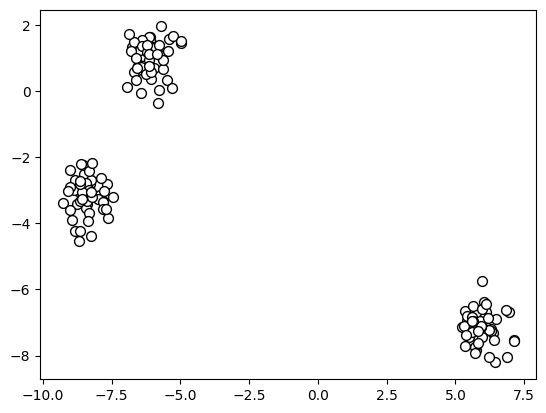

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
# create dataset
X, y = make_blobs(
n_samples=150, n_features=2,
centers=3, cluster_std=0.5,
shuffle=True, random_state=173142
)
# plot
plt.scatter(
X[:, 0], X[:, 1],
c='white', marker='o',
edgecolor='black', s=50
)
plt.show()

In [ ]:
from sklearn.cluster import KMeans
km = KMeans(
n_clusters=3, init='random',
n_init=10, max_iter=300,
tol=1e-04, random_state=173142
)
y_km = km.fit_predict(X)

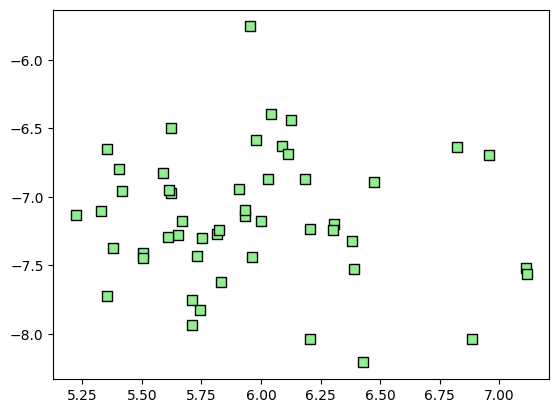

In [ ]:
plt.scatter(
X[y_km == 0, 0], X[y_km == 0, 1],
s=50, c='lightgreen',
marker='s', edgecolor='black',
label='cluster 1'
)

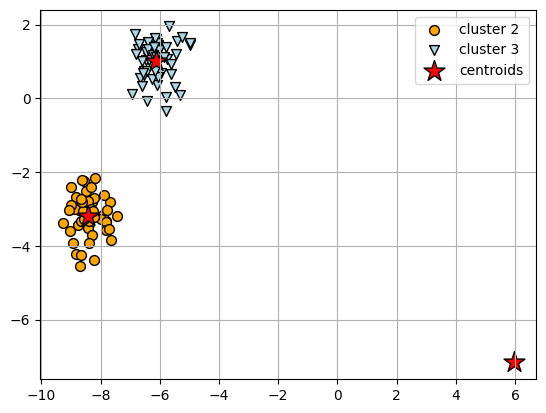

In [ ]:
plt.scatter(
X[y_km == 1, 0], X[y_km == 1, 1],
s=50, c='orange',
marker='o', edgecolor='black',
label='cluster 2'
)
plt.scatter(
X[y_km == 2, 0], X[y_km == 2, 1],
s=50, c='lightblue',
marker='v', edgecolor='black',
label='cluster 3'
)
# plot the centroids
plt.scatter(
km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
s=250, marker='*',
c='red', edgecolor='black',
label='centroids'
)
plt.legend(scatterpoints=1)
plt.grid()
plt.show()

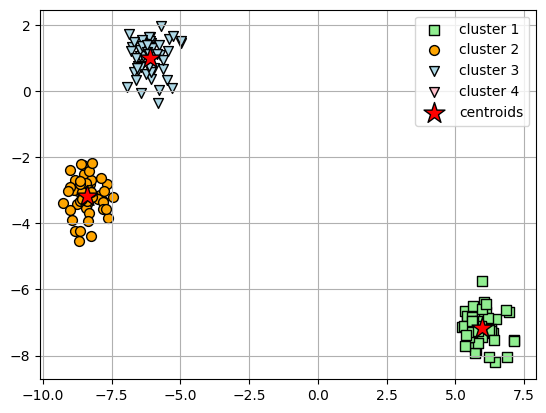

In [ ]:
# plot the 4 clusters
plt.scatter(
X[y_km == 0, 0], X[y_km == 0, 1],
s=50, c='lightgreen',
marker='s', edgecolor='black',
label='cluster 1'
)
plt.scatter(
X[y_km == 1, 0], X[y_km == 1, 1],
s=50, c='orange',
marker='o', edgecolor='black',
label='cluster 2'
)
plt.scatter(
X[y_km == 2, 0], X[y_km == 2, 1],
s=50, c='lightblue',
marker='v', edgecolor='black',
label='cluster 3'
)
plt.scatter(
X[y_km == 3, 0], X[y_km == 3, 1],
s=50, c='pink',
marker='v', edgecolor='black',
label='cluster 4'
)
# plot the centroids
plt.scatter(
km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
s=250, marker='*',
c='red', edgecolor='black',
label='centroids'
)
plt.legend(scatterpoints=1)
plt.grid()
plt.show()

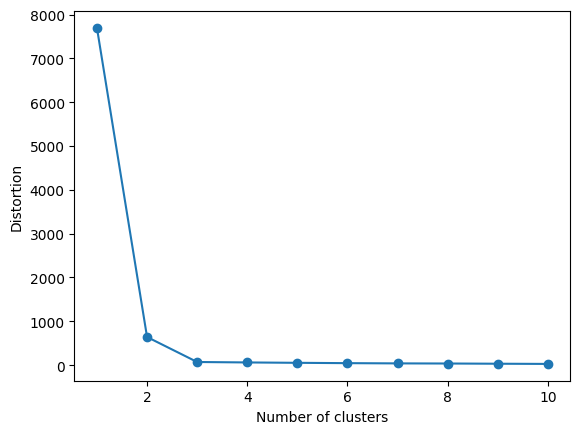

In [ ]:
# calculate distortion for a range of number of cluster
distortions = []
for i in range(1, 11):
#zmieniamy liczbe klastrow jakie ma odnalezc algorytm
  km = KMeans(
    n_clusters=i, init='random',
    n_init=10, max_iter=300,
    tol=1e-04, random_state=173142
  )
  km.fit(X)
  distortions.append(km.inertia_)
# plot
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

Działanie algorytmu k-means:

**Zalety**

```
Są stosunkowo proste do wdrożenia.
Możliwość skalowania do dużych zbiorów danych.
Możliwość skalowania do dużych zbiorów danych.
Zawsze się zbiega.
Pozwala na uruchomienie pozycji centroidów w stanie wstępnym.
Płynnie dostosowuje się do nowych przykładów.
Można je uogólnić do klastrów o różnych kształtach i rozmiarach, np. eliptycznych.
```

**Wady:**

```
K musi być wybrany ręcznie.
Wyniki zależą od wartości początkowych.
W przypadku niskiej wartości K możesz ograniczyć tę zależność, wykonując kilkakrotnie algorytm k-średnich z różnymi wartościami początkowymi i wybierając najlepszy wynik. W miarę wzrostu wartości musisz wypełnić rdzeń, aby wybrać lepsze początkowe centroidy.
Trudności z tworzeniem klastrów danych o zmiennych rozmiarach i gęstościach bez ich uogólniania.
Wyjątki w przypadku grupowania kluster według trudności
Punkty środkowe mogą być przeciągane przez wartości odstające lub mogą tworzyć własny klaster zamiast być ignorowane. Rozważ usunięcie lub przycięcie wartości odstających przed zgrupowaniem.
Trudności w skalowaniu wraz z liczbą wymiarów.
```

Algorytm DBSCAN

In [ ]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.3, min_samples=10)
db = db.fit(X)
#tutaj trafiaja etykiety rozpoznanych klastrow punktow
labels = db.labels_

In [ ]:
print(labels)
#pokazuje jakie etykiety algorytm nadal
print(set(labels) )

[-1 -1 -1 -1  2 -1  0 -1 -1  2 -1 -1  2 -1  1 -1  2 -1 -1 -1 -1 -1 -1 -1
  2 -1 -1 -1 -1 -1 -1  2 -1 -1  2  2 -1  2 -1 -1  2  1 -1  2  0  1 -1  0
  1 -1 -1  1 -1  0  0 -1  0  0 -1 -1 -1 -1 -1  1 -1 -1 -1 -1 -1 -1 -1  1
 -1 -1  0 -1  1 -1 -1  2 -1 -1  1 -1 -1 -1 -1  0 -1  2  2 -1  2  2 -1 -1
 -1  1 -1  1 -1 -1  2 -1 -1 -1 -1  1 -1  0  2 -1  1  0 -1  0 -1  0 -1  1
  0 -1 -1 -1 -1 -1  2  1 -1 -1 -1 -1 -1 -1  0 -1 -1  2  0 -1  0 -1  0 -1
 -1  2  1  0 -1  0]
{np.int64(0), np.int64(1), np.int64(2), np.int64(-1)}


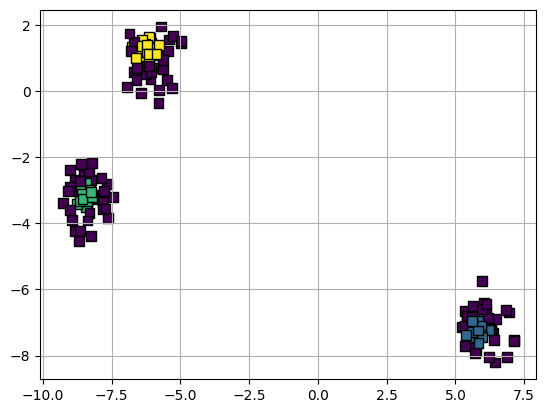

In [ ]:
# plot the 4 clusters
#klaster oznaczony etykieta 0, bo "y_km==0"
plt.scatter(
X[:,0], X[:,1],
s=50, c=labels,
marker='s', edgecolor='black',
)
#plt.legend(scatterpoints=1)
plt.grid()
plt.show()

Zalety:

    Odporny na wpływ obserwacji odstających.
    Znakomicie radzi sobie z grupami o niewypukłym kształcie.
    Daje dobre rezultaty – zachowując przy tym relatywnie szybkie działanie.
    Daje możliwość definiowania wielu miar odległości – jest to problemem w przypadku np. k-średnich.

Wady:

    Nie daje możliwości definiowania a priori liczby segmentów – liczba segmentów zależy od liczby obserwacji i dobranych parametrów.
    Dobór odpowiednich parametrów bywa dosyć problematyczny – ich optymalizacja bywa długa i uciążliwa, gdyż nie ma jednej sprawdzonej metody (istnieje kilka podejść, które przedstawię w przyszłości).


**Lab 2**

In [ ]:
import numpy as np
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

dane = np.load('dane_10marca-v3.npy')

print("Wymiar danych:", dane.shape)

kmeans_raw = KMeans(n_clusters=3, random_state=42)
labels_km_raw = kmeans_raw.fit_predict(dane)
sil_km_raw = silhouette_score(dane, labels_km_raw)
print(f"K-Means (surowe dane) Silhouette Score: {sil_km_raw:.4f}")

dbscan_raw = DBSCAN(eps=9.4, min_samples=5)
labels_db_raw = dbscan_raw.fit_predict(dane)

if len(set(labels_db_raw)) > 1:
    mask_raw = labels_db_raw != -1
    if len(set(labels_db_raw[mask_raw])) > 1:
        sil_db_raw = silhouette_score(dane[mask_raw], labels_db_raw[mask_raw])
        print(f"DBSCAN (surowe dane) Silhouette Score (bez szumu): {sil_db_raw:.4f}")
else:
    print("DBSCAN na surowych danych nie znalazł wyraźnych klastrów.")

Wymiar danych: (2000, 150)
K-Means (surowe dane) Silhouette Score: 0.2441
DBSCAN na surowych danych nie znalazł wyraźnych klastrów.


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
dane_scaled = scaler.fit_transform(dane)

pca = PCA(n_components=0.95, random_state=42)
dane_pca = pca.fit_transform(dane_scaled)

print(f"Liczba wymiarów po PCA: {dane_pca.shape[1]}")

Liczba wymiarów po PCA: 55


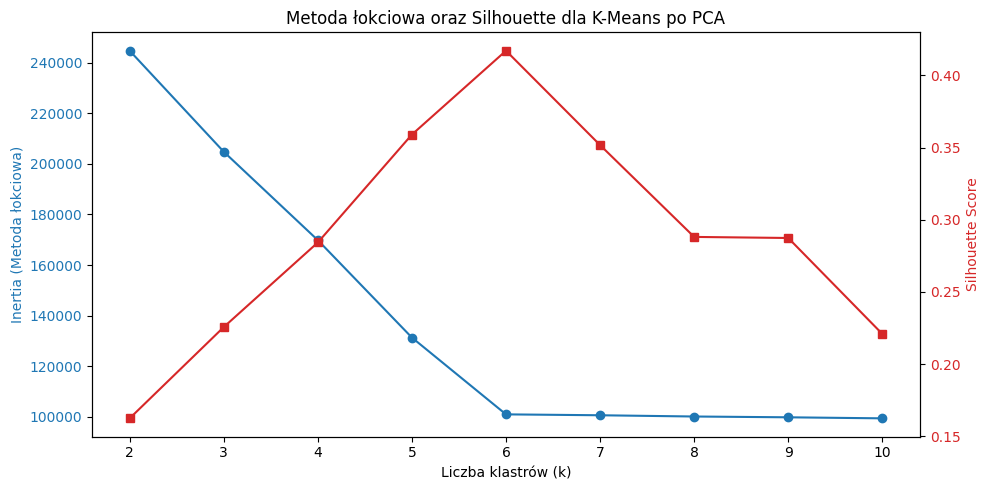

In [ ]:
import matplotlib.pyplot as plt

inertia = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(dane_pca)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(dane_pca, labels))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Liczba klastrów (k)')
ax1.set_ylabel('Inertia (Metoda łokciowa)', color=color)
ax1.plot(k_range, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_scores, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Metoda łokciowa oraz Silhouette dla K-Means po PCA')
fig.tight_layout()
plt.show()

Oszacowane optymalne eps: 10.1635


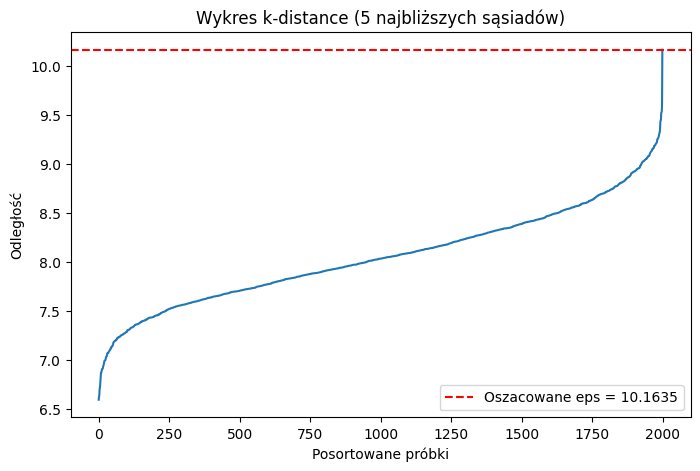

In [ ]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(dane_pca)
distances, indices = nn.kneighbors(dane_pca)

distances = np.sort(distances[:, -1])
knee = np.argmax(np.diff(distances)) + 1
eps_est = distances[knee]

print(f"Oszacowane optymalne eps: {eps_est:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.axhline(y=eps_est, color='r', linestyle='--', label=f'Oszacowane eps = {eps_est:.4f}')
plt.title("Wykres k-distance (5 najbliższych sąsiadów)")
plt.xlabel("Posortowane próbki")
plt.ylabel("Odległość")
plt.legend()
plt.show()

K-Means po PCA (k=10) - Silhouette: 0.2208
DBSCAN po PCA - Znalezione klastry: 6, Szum: 0
DBSCAN po PCA - Silhouette (bez szumu): 0.4171


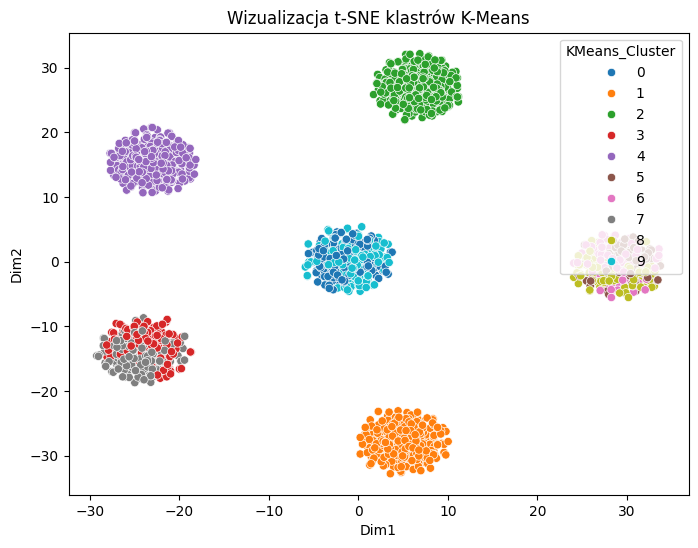

In [ ]:
import pandas as pd
import seaborn as sn
from sklearn.manifold import TSNE

best_k = 10
kmeans_pca = KMeans(n_clusters=best_k, random_state=42)
labels_km_pca = kmeans_pca.fit_predict(dane_pca)
print(f"K-Means po PCA (k={best_k}) - Silhouette: {silhouette_score(dane_pca, labels_km_pca):.4f}")

dbscan_pca = DBSCAN(eps=eps_est, min_samples=5)
labels_db_pca = dbscan_pca.fit_predict(dane_pca)

n_clusters_db = len(set(labels_db_pca)) - (1 if -1 in labels_db_pca else 0)
n_noise_db = list(labels_db_pca).count(-1)
print(f"DBSCAN po PCA - Znalezione klastry: {n_clusters_db}, Szum: {n_noise_db}")

mask = labels_db_pca != -1
if len(set(labels_db_pca[mask])) > 1:
    print(f"DBSCAN po PCA - Silhouette (bez szumu): {silhouette_score(dane_pca[mask], labels_db_pca[mask]):.4f}")

tsne = TSNE(n_components=2, random_state=42)
dane_tsne = tsne.fit_transform(dane_pca)

df_tsne = pd.DataFrame(dane_tsne, columns=['Dim1', 'Dim2'])
df_tsne['KMeans_Cluster'] = labels_km_pca

plt.figure(figsize=(8, 6))
sn.scatterplot(x='Dim1', y='Dim2', hue='KMeans_Cluster', palette='tab10', data=df_tsne, legend='full')
plt.title('Wizualizacja t-SNE klastrów K-Means')
plt.show()

**Wnioski**

## Wnioski

### K-Means

Na surowych danych (2000 próbek, 150 cech) algorytm K-Means uzyskał
Silhouette Score równy 0.2441, co wskazuje na słabą separację klastrów.
Po zastosowaniu standaryzacji (StandardScaler) i redukcji wymiarowości
metodą PCA — która zachowała 95% wariancji, redukując przestrzeń
z 150 do 55 wymiarów — jakość klasteryzacji była silnie zależna od
doboru liczby klastrów. Przy k=10 Silhouette Score wyniósł 0.2208,
a więc nieznacznie poniżej wyniku na surowych danych. Natomiast przy
optymalnym k=6, wyznaczonym na podstawie zgodności metody łokciowej
i maksymalnego Silhouette Score, wynik wzrósł do około 0.42, a inercja
spadła z około 243 000 (k=2) do około 100 000. Świadczy to o tym, że
PCA rzeczywiście poprawia jakość klasteryzacji, lecz tylko przy
odpowiednio dobranym k — nadmierna liczba klastrów niweluje tę korzyść.

### DBSCAN

Na surowych danych DBSCAN (eps=10.1635, min_samples=5) nie wykrył
wyraźnych klastrów — większość punktów została sklasyfikowana jako
szum lub trafiła do jednego dominującego skupiska. Po zastosowaniu
standaryzacji i PCA oraz doborze eps na podstawie wykresu k-distance
algorytm wykrył 6 klastrów bez żadnego punktu szumu, osiągając
Silhouette Score równy 0.4171. Jest to wynik zbliżony do K-Means
przy optymalnym k=6, co sugeruje, że oba algorytmy zidentyfikowały
zbliżoną strukturę grupową w danych. Warto jednak zaznaczyć, że wykres
k-distance nie wykazał wyraźnego przegięcia, co wskazuje na brak
dobrze zdefiniowanej struktury gęstościowej — dobór eps pozostaje
nietrywialny i silnie wpływa na końcowy wynik.

### Porównanie ogólne

Preprocessing (standaryzacja + PCA) miał kluczowy wpływ na jakość
klasteryzacji obu algorytmów, przy czym efekt był wyraźniejszy dla
DBSCAN — na surowych danych algorytm nie znalazł sensownych skupisk,
natomiast po PCA uzyskał Silhouette Score 0.4171. K-Means, choć już
na surowych danych dawał pewną separację (0.2441), osiągnął porównywalny
wynik (≈0.42) dopiero przy optymalnym k=6 po PCA. Obydwa algorytmy
zgodnie wskazały 6 jako liczbę skupisk obecnych w danych. K-Means
wymaga jednak jawnego podania k, a jego jakość jest wrażliwa na tę
decyzję — nieoptymalne k=10 dało wynik gorszy niż dane surowe.
DBSCAN identyfikuje liczbę klastrów automatycznie, lecz kosztem
trudniejszego doboru parametrów eps i min_samples.